# Recitation 6 - Problem 1

用 Godunov / upwind 有限体积法求解 Burgers 方程的 Riemann 问题：

\[
u_t + u u_x = 0, \qquad
u(x,0)=
\begin{cases}
A, & x<0,\\
B, & x>0.
\end{cases}
\]

本 notebook 完成的内容：

1. 将方程写成守恒形式；
2. 实现 Godunov 数值通量并求数值解；
3. 比较 shock (`A>B`) 与 rarefaction (`A<B`) 两种情形的数值解和精确解；
4. 给出时空图与 `L^1` 误差收敛结果，并总结观察。

## 1. 守恒形式与精确解

Burgers 方程可以写成守恒形式

\[
u_t + f(u)_x = 0, \qquad f(u)=\frac{u^2}{2}.
\]

对局部 Riemann 问题，Godunov 通量为

\[
F(u_L,u_R)=
\begin{cases}
f(u_L), & u_L>u_R,\ \frac{u_L+u_R}{2}\ge 0,\\
f(u_R), & u_L>u_R,\ \frac{u_L+u_R}{2}< 0,\\
f(u_L), & u_L\le u_R,\ u_L\ge 0,\\
f(u_R), & u_L\le u_R,\ u_R\le 0,\\
0, & u_L < 0 < u_R.
\end{cases}
\]

对本题的 Riemann 初值，精确解可写成更熟悉的分段形式：

- 若 `A > B`，形成 shock，传播速度
  \[
  s=\frac{f(A)-f(B)}{A-B}=\frac{A+B}{2},
  \]
  因而
  \[
  u(x,t)=
  \begin{cases}
  A,& x<st,\\
  B,& x>st.
  \end{cases}
  \]
- 若 `A < B`，形成 rarefaction fan，
  \[
  u(x,t)=
  \begin{cases}
  A,& x<At,\\
  x/t,& At\le x\le Bt,\\
  B,& x>Bt.
  \end{cases}
  \]

下面直接实现数值格式。

In [112]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def physical_flux(u):
    return 0.5 * u**2


def godunov_flux(uL, uR):
    """Vectorized Godunov flux for Burgers' equation."""
    uL = np.asarray(uL, dtype=float)
    uR = np.asarray(uR, dtype=float)

    shock = uL > uR
    shock_speed = 0.5 * (uL + uR)
    flux_shock = np.where(shock_speed >= 0.0, physical_flux(uL), physical_flux(uR))

    flux_rare = np.where(
        uL >= 0.0,
        physical_flux(uL),
        np.where(uR <= 0.0, physical_flux(uR), 0.0),
    )

    return np.where(shock, flux_shock, flux_rare)


def exact_solution(x, t, A, B):
    x = np.asarray(x, dtype=float)
    if t <= 0:
        return np.where(x < 0.0, A, B).astype(float)

    if A > B:
        s = 0.5 * (A + B)
        return np.where(x < s * t, A, B).astype(float)

    out = np.empty_like(x)
    out[x < A * t] = A
    out[x > B * t] = B
    mask = (x >= A * t) & (x <= B * t)
    out[mask] = x[mask] / t
    return out


def solve_riemann(
    A,
    B,
    N=400,
    xlim=(-2.0, 2.0),
    t_final=0.5,
    CFL=0.9,
    store_history=False,
    history_stride=5,
):
    xmin, xmax = xlim
    dx = (xmax - xmin) / N
    x = xmin + (np.arange(N) + 0.5) * dx
    u = np.where(x < 0.0, A, B).astype(float)
    t = 0.0

    history = [u.copy()] if store_history else None
    times = [t] if store_history else None

    step_count = 0
    while t < t_final - 1e-14:
        max_speed = max(np.max(np.abs(u)), 1e-12)
        dt = min(CFL * dx / max_speed, t_final - t)

        u_ext = np.concatenate(([A], u, [B]))
        F = godunov_flux(u_ext[:-1], u_ext[1:])
        u = u - dt / dx * (F[1:] - F[:-1])

        t += dt
        step_count += 1

        if store_history and (step_count % history_stride == 0 or t >= t_final - 1e-14):
            history.append(u.copy())
            times.append(t)

    result = {"x": x, "u": u, "t": t, "dx": dx}
    if store_history:
        result["history"] = np.array(history)
        result["times"] = np.array(times)
    return result


def l1_error(x, u_num, t, A, B):
    dx = x[1] - x[0]
    u_ex = exact_solution(x, t, A, B)
    return dx * np.sum(np.abs(u_num - u_ex))


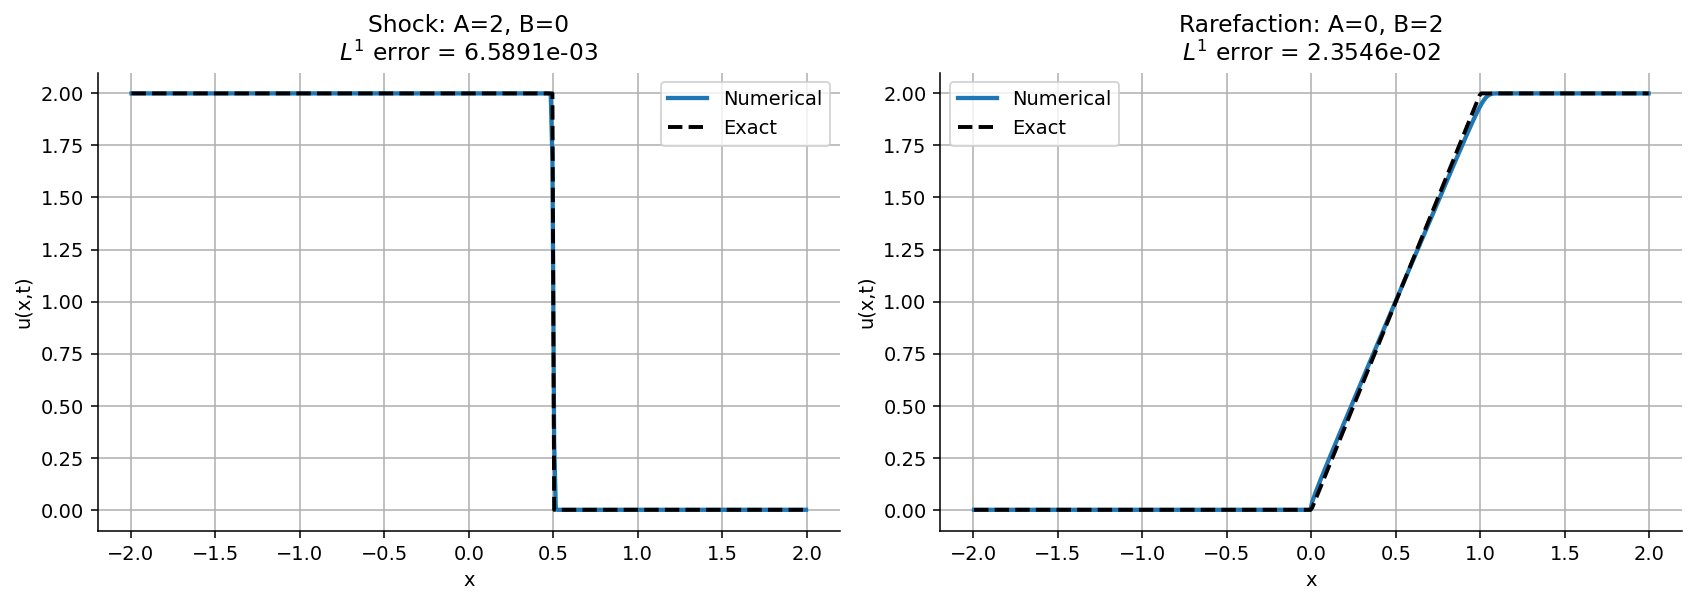

In [113]:
cases = [
    (2.0, 0.0, "Shock: A=2, B=0"),
    (0.0, 2.0, "Rarefaction: A=0, B=2"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for ax, (A, B, title) in zip(axes, cases):
    sol = solve_riemann(A, B, N=400, t_final=0.5, CFL=0.9)
    x, u_num, t = sol["x"], sol["u"], sol["t"]
    u_ex = exact_solution(x, t, A, B)
    err = l1_error(x, u_num, t, A, B)

    ax.plot(x, u_num, lw=2.2, label="Numerical")
    ax.plot(x, u_ex, "k--", lw=2.0, label="Exact")
    ax.set_title(f"{title}\n$L^1$ error = {err:.4e}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,t)")
    ax.legend()

plt.show()

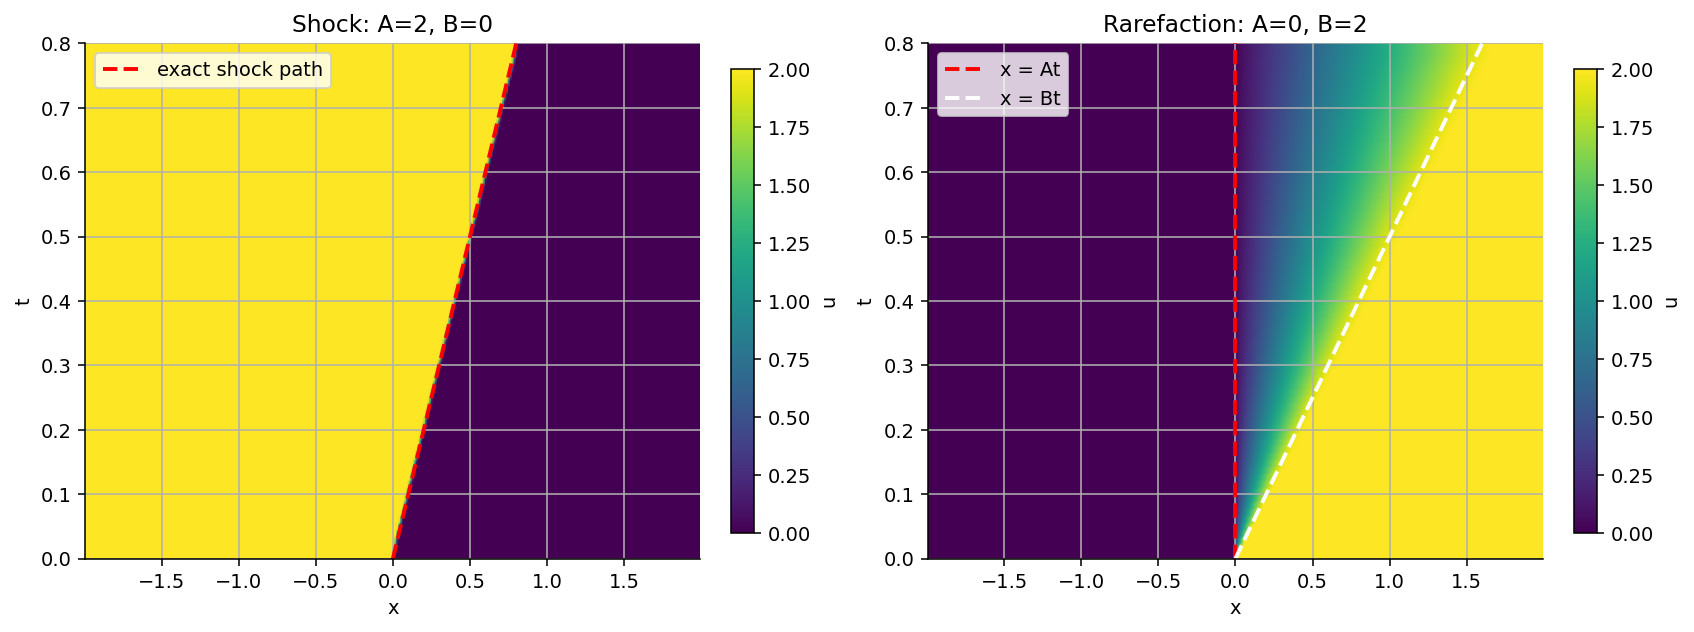

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)

for ax, (A, B, title) in zip(axes, cases):
    sol = solve_riemann(
        A,
        B,
        N=320,
        t_final=0.8,
        CFL=0.9,
        store_history=True,
        history_stride=2,
    )
    x = sol["x"]
    times = sol["times"]
    history = sol["history"]

    im = ax.imshow(
        history,
        extent=[x[0], x[-1], times[0], times[-1]],
        aspect="auto",
        origin="lower",
        cmap="viridis",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("t")

    if A > B:
        ax.plot(0.5 * (A + B) * times, times, "r--", lw=2, label="exact shock path")
    else:
        ax.plot(A * times, times, "r--", lw=2, label="x = At")
        ax.plot(B * times, times, "w--", lw=2, label="x = Bt")
    ax.legend(loc="upper left")
    fig.colorbar(im, ax=ax, shrink=0.9, label="u")

plt.show()

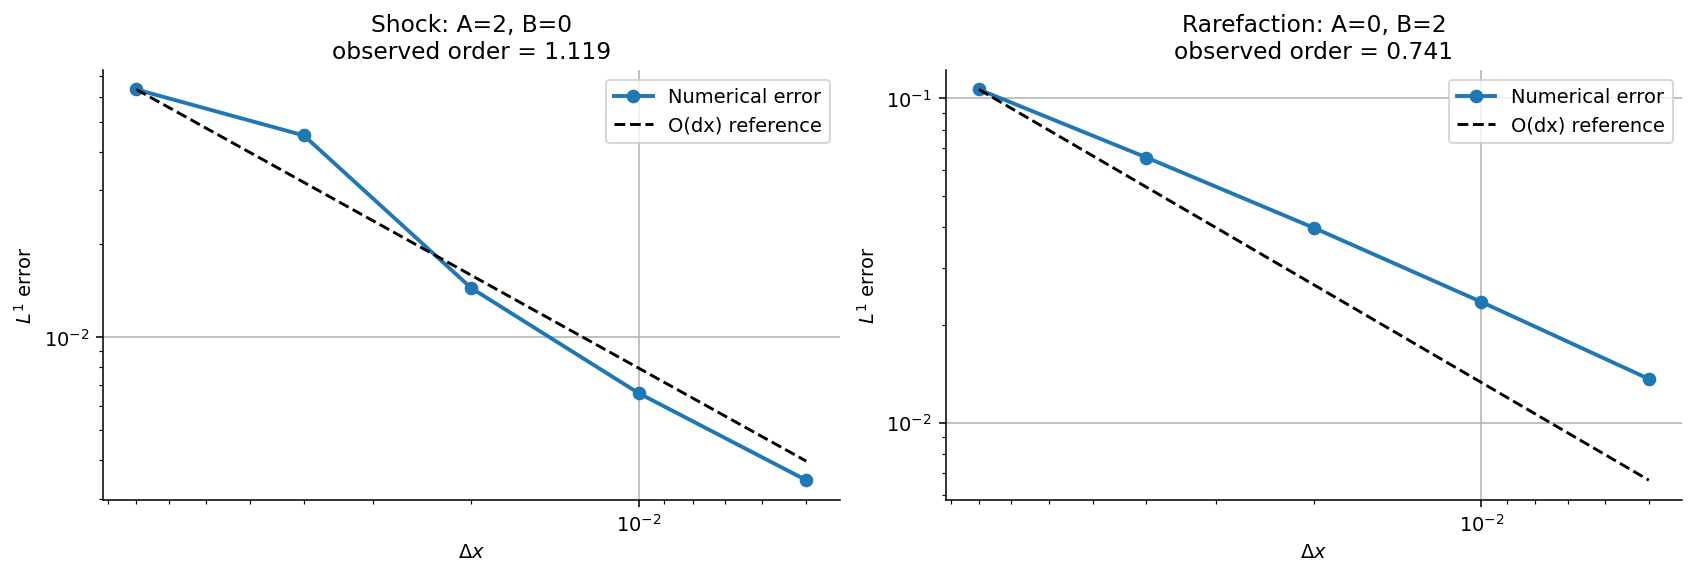

In [115]:
def convergence_data(A, B, Ns=(50, 100, 200, 400, 800), t_final=0.5):
    dxs = []
    errors = []
    for N in Ns:
        sol = solve_riemann(A, B, N=N, t_final=t_final, CFL=0.9)
        dxs.append(sol["dx"])
        errors.append(l1_error(sol["x"], sol["u"], sol["t"], A, B))
    dxs = np.array(dxs)
    errors = np.array(errors)
    order = np.polyfit(np.log(dxs), np.log(errors), 1)[0]
    return dxs, errors, order


fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for ax, (A, B, title) in zip(axes, cases):
    dxs, errors, order = convergence_data(A, B)
    ax.loglog(dxs, errors, "o-", lw=2, label="Numerical error")
    ax.loglog(dxs, errors[0] * (dxs / dxs[0]), "k--", label="O(dx) reference")
    ax.set_title(f"{title}\nobserved order = {order:.3f}")
    ax.set_xlabel("$\\Delta x$")
    ax.set_ylabel("$L^1$ error")
    ax.invert_xaxis()
    ax.legend()

plt.show()

## 2. 结果观察

### Shock (`A > B`)

- 数值解能够给出正确的 shock 传播方向与传播速度，位置与理论直线 `x = ((A+B)/2)t` 一致；
- 但间断不会保持成一条“竖直跳变”，而是被摊成若干个网格宽度，这就是一阶 Godunov 格式的**数值耗散**；
- 整体没有出现明显的非物理振荡，这与 Godunov 格式的单调性一致。

### Rarefaction (`A < B`)

- 数值解能够自动选择熵解，形成近似的 rarefaction fan；
- 扇形内部的线性轮廓 `u=x/t` 能够被较好恢复，但左右边界 `x=At`、`x=Bt` 同样会被轻微抹平；
- 与 shock 情形相比，这里的误差主要表现为平滑区域的轻微扩散，而不是间断层的展宽。

### 收敛性

- `L^1` 误差对 `\Delta x` 的双对数图斜率接近 1；
- 这说明该 Godunov 有限体积格式在本题中表现出**一阶收敛**；
- 在含间断的 shock 情形下，误差常数更大，但整体阶数仍接近一阶。

## 3. 结论

对 Burgers 方程的 Riemann 问题，Godunov/upwind 有限体积法能稳定地捕捉：

- shock 的正确传播速度；
- rarefaction fan 的正确熵解结构。

它的主要缺点是一阶格式带来的数值耗散，因此 shock 会被抹宽，rarefaction 的边界也会被平滑。

# Problem 4 - Poisson Equation Again

考虑

\[
-u''(x)=1,\qquad x\in(0,1),\qquad u'(0)=0,\quad u(1)=0.
\]

精确解为

\[
u(x)=\frac{1-x^2}{2}.
\]

对满足 `v(1)=0` 的测试函数做分部积分，可得弱形式：

\[
\int_0^1 u'(x)v'(x)\,dx=\int_0^1 v(x)\,dx.
\]

这里 `x=0` 处的 Neumann 条件是自然边界条件，因此只需要在 `x=1` 处施加 Dirichlet 约束。

本题分别使用两类有限元空间：

1. 仅使用 hat basis functions；
2. 在每个单元上额外加入一个 midpoint bubble basis function。

下面直接搭建两种离散系统，并完成题目的 `a) b) c)`。

In [116]:
import numpy as np
import matplotlib.pyplot as plt


def exact_u_p4(x):
    x = np.asarray(x, dtype=float)
    return 0.5 * (1.0 - x**2)


def solve_hat_fem(N):
    """Linear FEM on a uniform mesh with N elements.

    Unknown nodal values are u(x_0), ..., u(x_{N-1}); x_N=1 is fixed by Dirichlet BC.
    """
    h = 1.0 / N
    K = np.zeros((N, N))
    F = np.zeros(N)

    ke = (1.0 / h) * np.array([[1.0, -1.0], [-1.0, 1.0]])
    fe = h * np.array([0.5, 0.5])

    for e in range(N):
        nodes = [e, e + 1]
        for a, A in enumerate(nodes):
            if A == N:
                continue
            F[A] += fe[a]
            for b, B in enumerate(nodes):
                if B == N:
                    continue
                K[A, B] += ke[a, b]

    u_free = np.linalg.solve(K, F)
    nodes = np.linspace(0.0, 1.0, N + 1)
    u_nodes = np.concatenate([u_free, [0.0]])
    return nodes, u_nodes


def solve_enriched_fem(N):
    """Quadratic enrichment: [left hat, bubble, right hat] on each element."""
    h = 1.0 / N
    n_node_dofs = N
    n_bubble_dofs = N
    ndof = n_node_dofs + n_bubble_dofs

    K = np.zeros((ndof, ndof))
    F = np.zeros(ndof)

    # Local basis on [0,1]:
    # phi_L = 1-xi, psi = 4*xi*(1-xi), phi_R = xi
    ke = (1.0 / h) * np.array(
        [
            [1.0, 0.0, -1.0],
            [0.0, 16.0 / 3.0, 0.0],
            [-1.0, 0.0, 1.0],
        ]
    )
    fe = h * np.array([0.5, 2.0 / 3.0, 0.5])

    def node_id(i):
        return i

    def bubble_id(e):
        return n_node_dofs + e

    for e in range(N):
        local_to_global = [node_id(e), bubble_id(e), None if e + 1 == N else node_id(e + 1)]
        for a, A in enumerate(local_to_global):
            if A is None:
                continue
            F[A] += fe[a]
            for b, B in enumerate(local_to_global):
                if B is None:
                    continue
                K[A, B] += ke[a, b]

    coeff = np.linalg.solve(K, F)
    nodes = np.linspace(0.0, 1.0, N + 1)
    nodal = np.concatenate([coeff[:n_node_dofs], [0.0]])
    bubble = coeff[n_node_dofs:]
    return nodes, nodal, bubble


def eval_hat_solution(x, nodes, u_nodes):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    N = len(nodes) - 1
    for e in range(N):
        xl, xr = nodes[e], nodes[e + 1]
        mask = (x >= xl) & ((x <= xr) if e == N - 1 else (x < xr))
        xi = (x[mask] - xl) / (xr - xl)
        out[mask] = u_nodes[e] * (1.0 - xi) + u_nodes[e + 1] * xi
    return out


def eval_enriched_solution(x, nodes, u_nodes, bubble):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    N = len(nodes) - 1
    for e in range(N):
        xl, xr = nodes[e], nodes[e + 1]
        mask = (x >= xl) & ((x <= xr) if e == N - 1 else (x < xr))
        xi = (x[mask] - xl) / (xr - xl)
        out[mask] = (
            u_nodes[e] * (1.0 - xi)
            + u_nodes[e + 1] * xi
            + bubble[e] * 4.0 * xi * (1.0 - xi)
        )
    return out


N = 3
nodes           = [0.         0.33333333 0.66666667 1.        ]
hat nodal DOFs  = [0.5        0.44444444 0.27777778 0.        ]
enriched nodal  = [0.5        0.44444444 0.27777778 0.        ]
bubble DOFs     = [0.01388889 0.01388889 0.01388889]
exact nodal     = [0.5        0.44444444 0.27777778 0.        ]
max |u - u_hat| on dense grid      = 0.013888867133144633
max |u - u_enriched| on dense grid = 1.6653345369377348e-16


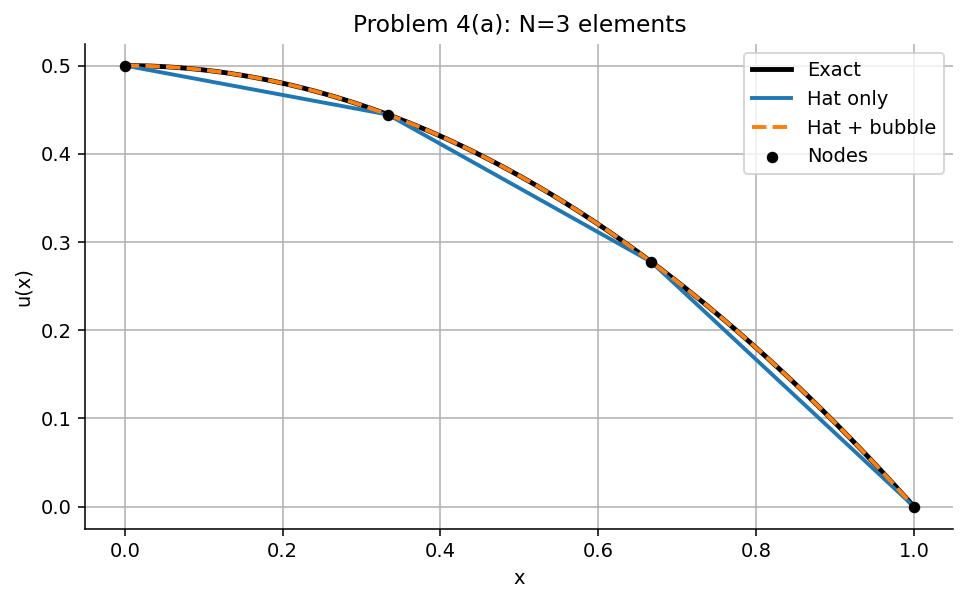

In [117]:
# Part (a): the original 3-element mesh
N = 3
nodes_hat, u_hat = solve_hat_fem(N)
nodes_en, u_en, bubble_en = solve_enriched_fem(N)

x_plot = np.linspace(0.0, 1.0, 800)
u_exact_plot = exact_u_p4(x_plot)
u_hat_plot = eval_hat_solution(x_plot, nodes_hat, u_hat)
u_en_plot = eval_enriched_solution(x_plot, nodes_en, u_en, bubble_en)

print("N = 3")
print("nodes           =", nodes_en)
print("hat nodal DOFs  =", u_hat)
print("enriched nodal  =", u_en)
print("bubble DOFs     =", bubble_en)
print("exact nodal     =", exact_u_p4(nodes_en))
print("max |u - u_hat| on dense grid      =", np.max(np.abs(u_exact_plot - u_hat_plot)))
print("max |u - u_enriched| on dense grid =", np.max(np.abs(u_exact_plot - u_en_plot)))

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, u_exact_plot, "k-", lw=2.5, label="Exact")
plt.plot(x_plot, u_hat_plot, lw=2.0, label="Hat only")
plt.plot(x_plot, u_en_plot, "--", lw=2.0, label="Hat + bubble")
plt.scatter(nodes_en, exact_u_p4(nodes_en), color="k", s=24, zorder=4, label="Nodes")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Problem 4(a): N=3 elements")
plt.legend()
plt.show()

   N          h      max err hat   max err enriched    nodal err hat   nodal err enriched
   4    0.25000   7.81250000e-03     1.11022302e-16   0.00000000e+00       0.00000000e+00
   8    0.12500   1.95312500e-03     1.11022302e-16   0.00000000e+00       0.00000000e+00
  16    0.06250   4.88281250e-04     1.11022302e-16   0.00000000e+00       0.00000000e+00
  32    0.03125   1.22062500e-04     1.11022302e-16   0.00000000e+00       0.00000000e+00
  64    0.01562   3.05156250e-05     1.11022302e-16   0.00000000e+00       0.00000000e+00

Observed order from full-domain max error (hat only): 2.000
Nodal errors are zero up to roundoff for both spaces on this special problem.


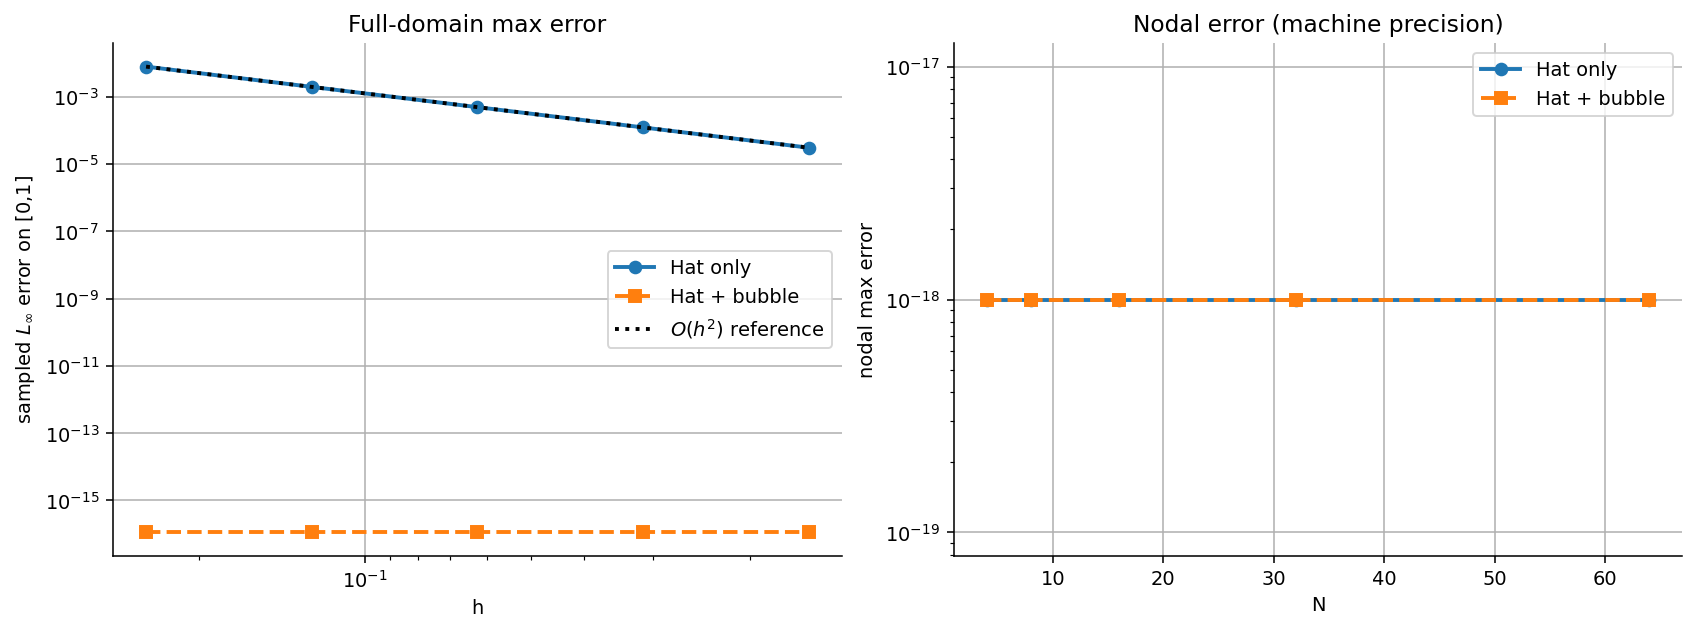

In [118]:
# Parts (b) and (c): error comparison for N = 4, 8, 16, 32, 64
Ns = np.array([4, 8, 16, 32, 64])
hs = 1.0 / Ns

max_err_hat = []
max_err_enriched = []
nodelinf_hat = []
nodelinf_enriched = []

for N in Ns:
    nodes_hat, u_hat = solve_hat_fem(N)
    nodes_en, u_en, bubble_en = solve_enriched_fem(N)

    x_dense = np.linspace(0.0, 1.0, 4001)
    err_hat = np.max(np.abs(exact_u_p4(x_dense) - eval_hat_solution(x_dense, nodes_hat, u_hat)))
    err_en = np.max(np.abs(exact_u_p4(x_dense) - eval_enriched_solution(x_dense, nodes_en, u_en, bubble_en)))

    max_err_hat.append(err_hat)
    max_err_enriched.append(err_en)
    nodelinf_hat.append(np.max(np.abs(exact_u_p4(nodes_hat) - u_hat)))
    nodelinf_enriched.append(np.max(np.abs(exact_u_p4(nodes_en) - u_en)))

max_err_hat = np.array(max_err_hat)
max_err_enriched = np.array(max_err_enriched)
nodelinf_hat = np.array(nodelinf_hat)
nodelinf_enriched = np.array(nodelinf_enriched)

print(f"{'N':>4} {'h':>10} {'max err hat':>16} {'max err enriched':>18} {'nodal err hat':>16} {'nodal err enriched':>20}")
for N, h, e1, e2, n1, n2 in zip(Ns, hs, max_err_hat, max_err_enriched, nodelinf_hat, nodelinf_enriched):
    print(f"{N:4d} {h:10.5f} {e1:16.8e} {e2:18.8e} {n1:16.8e} {n2:20.8e}")

order_hat = np.polyfit(np.log(hs), np.log(max_err_hat), 1)[0]
print(f"\nObserved order from full-domain max error (hat only): {order_hat:.3f}")
print("Nodal errors are zero up to roundoff for both spaces on this special problem.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)

axes[0].loglog(hs, max_err_hat, "o-", lw=2, label="Hat only")
axes[0].loglog(hs, max_err_enriched + 1e-18, "s--", lw=2, label="Hat + bubble")
axes[0].loglog(hs, max_err_hat[0] * (hs / hs[0])**2, "k:", lw=2, label="$O(h^2)$ reference")
axes[0].invert_xaxis()
axes[0].set_xlabel("h")
axes[0].set_ylabel("sampled $L_\infty$ error on [0,1]")
axes[0].set_title("Full-domain max error")
axes[0].legend()

axes[1].semilogy(Ns, nodelinf_hat + 1e-18, "o-", lw=2, label="Hat only")
axes[1].semilogy(Ns, nodelinf_enriched + 1e-18, "s--", lw=2, label="Hat + bubble")
axes[1].set_xlabel("N")
axes[1].set_ylabel("nodal max error")
axes[1].set_title("Nodal error (machine precision)")
axes[1].legend()

plt.show()

## Problem 4 Observations

### a) `N=3` enriched solution

- 只用 hat basis 时，有限元解是分段线性的；
- 加入每个单元上的 midpoint bubble 后，解在每个单元内变成分段二次；
- 对这道题，富集后的解与精确解在图上重合，误差只有浮点舍入量级；
- `N=3` 时三个 bubble 系数都等于 `1/72`，正好补上了每个单元内缺失的曲率。

### b) 不同网格数下的比较

- hat-only 解随着网格加密逐渐逼近精确解；
- hat + bubble 解在 `N=4,8,16,32,64` 上都几乎精确，因为精确解本身是二次多项式，而富集空间已经能逐单元精确表示这类函数；
- 因而在这道题里，bubble enrichment 不只是“更准确”，而是直接把误差降到了机器精度。

### c) 关于 `\|u-\hat u\|_\infty` 与阶数

- 若按题面中的**nodal error**理解，在所有网格上两种方法的节点值都与精确解一致，因此节点最大误差为 0（数值上是 roundoff level）；
- 若看更常用、也更有区分度的**全域最大误差**，hat-only 的误差满足 `O(h^2)`；
- 富集后的解对本题是“精确表示”，因此误差不再体现代数收敛，而是直接停在机器精度附近。

所以，这题最合理的结论是：

- hat basis only: 全域最大误差二阶；
- hat + bubble: 对该二次精确解达到机器精度；
- nodal error: 两种方法在本题上都呈现 superconvergent / exact nodal matching。

# Problem 6 - Heat Equation with a Grayscale Image Heat Source

在正方形区域 `\Omega=[-5,5]\times[-5,5]` 上考虑热方程

\[
u_t = \nu (u_{xx}+u_{yy}),\qquad \nu=0.2.
\]

边界与初值为：

- 外边界 `\partial\Omega` 固定温度 `u_L=1`；
- 把 `Lecture8/image.png` 映射为灰度图，并把灰度值线性映射到温度区间 `[u_L,u_H]=[1,10]`；
- 图像覆盖到区域内部后，整块图像区域作为**空间变温的固定热源**；
- 其余区域初值 `u(x,y,0)=u_L=1`。

下面保留题目的 `a) b)` 数值格式，同时把原先的 `THU` 多边形内部热源替换成灰度图热源。

## Problem 6(a): Five-Point Difference Formula

在网格点 `(x_i,y_j)` 处分别沿 `x,y` 做 Taylor 展开：

\[
u_{i+1,j}=u_{i,j}+u_x h_x+\frac12 u_{xx}h_x^2+\frac16 u_{xxx}h_x^3+O(h_x^4),
\]

\[
u_{i-1,j}=u_{i,j}-u_x h_x+\frac12 u_{xx}h_x^2-\frac16 u_{xxx}h_x^3+O(h_x^4).
\]

两式相加后得到

\[
u_{xx}(x_i,y_j)=\frac{u_{i+1,j}-2u_{i,j}+u_{i-1,j}}{h_x^2}+O(h_x^2).
\]

同理，

\[
u_{yy}(x_i,y_j)=\frac{u_{i,j+1}-2u_{i,j}+u_{i,j-1}}{h_y^2}+O(h_y^2).
\]

因此

\[
\nabla^2 u(x_i,y_j)
=
\frac{u_{i+1,j}-2u_{i,j}+u_{i-1,j}}{h_x^2}
+
\frac{u_{i,j+1}-2u_{i,j}+u_{i,j-1}}{h_y^2}
+ O(h_x^2+h_y^2),
\]

这就是二维 Laplacian 的五点差分格式。

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image


def locate_problem6_image():
    candidates = [
        Path("image.png"),
        Path("Lecture8") / "image.png",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find image.png for Problem 6.")


def build_image_heat_source(
    L2=5.0,
    dx=0.1,
    dy=0.1,
    TL=1.0,
    TH=10.0,
    image_center=(0.0, 0.0),
    image_height=7.2,
):
    x = np.arange(-L2, L2 + 0.5 * dx, dx)
    y = np.arange(-L2, L2 + 0.5 * dy, dy)
    X, Y = np.meshgrid(x, y, indexing="ij")

    image_path = locate_problem6_image()
    gray = np.asarray(Image.open(image_path).convert("L"), dtype=float)
    gray = (gray - gray.min()) / (gray.max() - gray.min() + 1e-12)

    img_h, img_w = gray.shape
    image_width = image_height * img_w / img_h
    cx, cy = image_center
    x0, x1 = cx - 0.5 * image_width, cx + 0.5 * image_width
    y0, y1 = cy - 0.5 * image_height, cy + 0.5 * image_height

    u = (X - x0) / (x1 - x0)
    v = (Y - y0) / (y1 - y0)
    source_mask = (u >= 0.0) & (u <= 1.0) & (v >= 0.0) & (v <= 1.0)

    cols = np.clip(np.round(u * (img_w - 1)).astype(int), 0, img_w - 1)
    rows = np.clip(np.round((1.0 - v) * (img_h - 1)).astype(int), 0, img_h - 1)

    source_temperature = np.full(X.shape, TL, dtype=float)
    source_temperature[source_mask] = TL + gray[rows[source_mask], cols[source_mask]] * (TH - TL)

    boundary_mask = np.zeros_like(source_mask, dtype=bool)
    boundary_mask[[0, -1], :] = True
    boundary_mask[:, [0, -1]] = True
    free_mask = ~(boundary_mask | source_mask)

    return {
        "x": x,
        "y": y,
        "X": X,
        "Y": Y,
        "source_mask": source_mask,
        "source_temperature": source_temperature,
        "boundary_mask": boundary_mask,
        "free_mask": free_mask,
        "image_path": str(image_path),
    }


def simulate_problem6(
    L2=5.0,
    dx=0.1,
    dy=0.1,
    dt=0.01,
    t_final=1.0,
    nu=0.2,
    TL=1.0,
    TH=10.0,
    snapshot_times=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
):
    stability_limit = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
    if dt > stability_limit + 1e-14:
        raise ValueError(f"Unstable explicit step: dt={dt} > {stability_limit:.5f}")

    data = build_image_heat_source(L2=L2, dx=dx, dy=dy, TL=TL, TH=TH)
    x = data["x"]
    y = data["y"]
    X = data["X"]
    Y = data["Y"]
    source_mask = data["source_mask"]
    source_temperature = data["source_temperature"]
    boundary_mask = data["boundary_mask"]
    free_mask = data["free_mask"]

    T = np.full(X.shape, TL, dtype=float)
    T[source_mask] = source_temperature[source_mask]

    snapshots = {0.0: T.copy()}
    n_steps = int(round(t_final / dt))
    snapshot_steps = {int(round(t / dt)): t for t in snapshot_times}

    for step in range(1, n_steps + 1):
        T_new = T.copy()

        lap = (
            (T[2:, 1:-1] - 2.0 * T[1:-1, 1:-1] + T[:-2, 1:-1]) / dx**2
            + (T[1:-1, 2:] - 2.0 * T[1:-1, 1:-1] + T[1:-1, :-2]) / dy**2
        )

        interior_free = free_mask[1:-1, 1:-1]
        T_new[1:-1, 1:-1][interior_free] = T[1:-1, 1:-1][interior_free] + nu * dt * lap[interior_free]

        T_new[boundary_mask] = TL
        T_new[source_mask] = source_temperature[source_mask]
        T = T_new

        if step in snapshot_steps:
            snapshots[snapshot_steps[step]] = T.copy()

    data.update(
        {
            "T": T,
            "snapshots": snapshots,
            "stability_limit": stability_limit,
        }
    )
    return data


Image source: image.png
Explicit stability limit: dt <= 0.01250
We use dt = 0.01, so the forward Euler scheme is stable here.
Source temperature range: [1.071, 10.000]
Final temperature range at t=1: [1.000, 10.000]


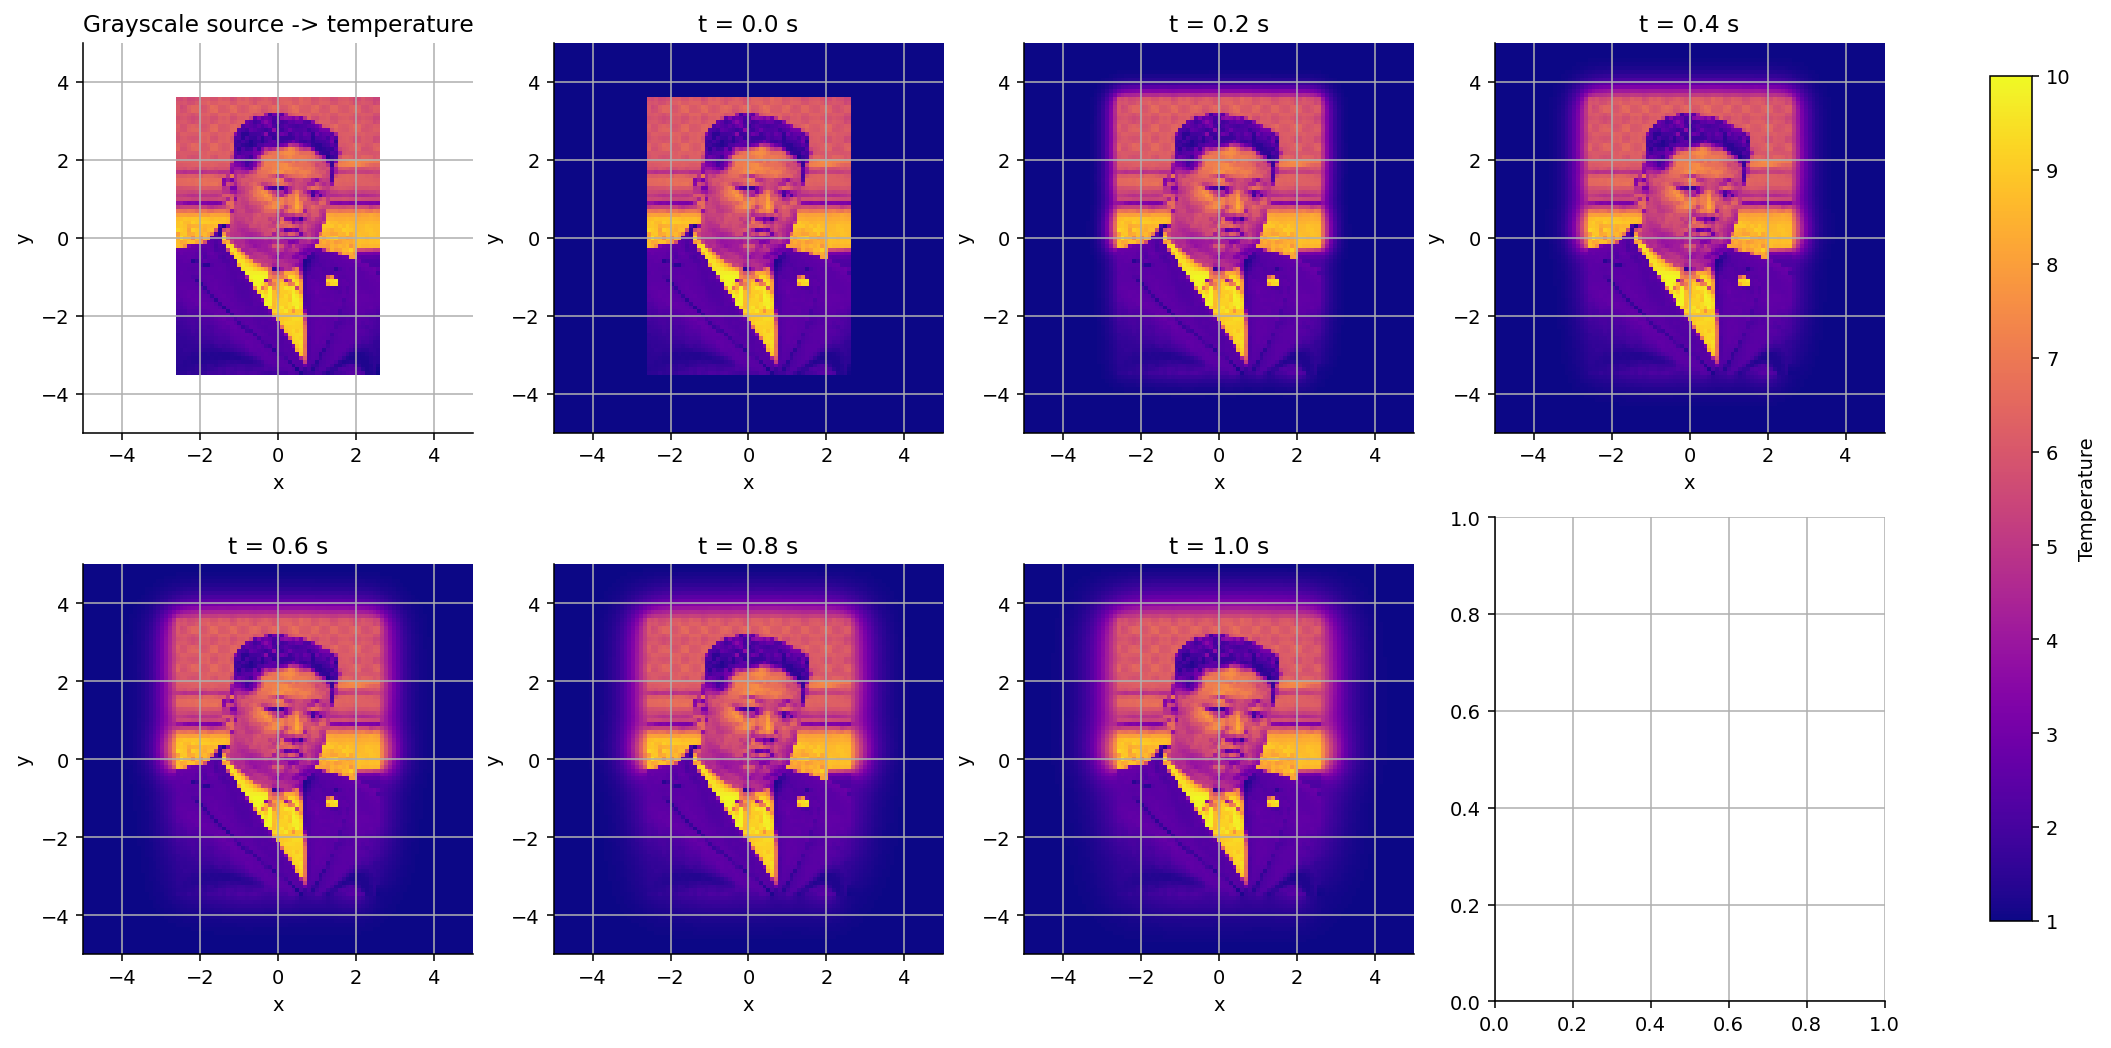

In [120]:
result6 = simulate_problem6()

print(f"Image source: {result6['image_path']}")
print(f"Explicit stability limit: dt <= {result6['stability_limit']:.5f}")
print("We use dt = 0.01, so the forward Euler scheme is stable here.")
print(
    f"Source temperature range: "
    f"[{result6['source_temperature'][result6['source_mask']].min():.3f}, "
    f"{result6['source_temperature'][result6['source_mask']].max():.3f}]"
)
print(
    f"Final temperature range at t=1: "
    f"[{result6['T'].min():.3f}, {result6['T'].max():.3f}]"
)

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), constrained_layout=True)

source_view = np.where(result6["source_mask"], result6["source_temperature"], np.nan)
im0 = axes[0, 0].imshow(
    source_view.T,
    extent=[result6["x"][0], result6["x"][-1], result6["y"][0], result6["y"][-1]],
    origin="lower",
    cmap="plasma",
    vmin=1.0,
    vmax=10.0,
    aspect="equal",
)
axes[0, 0].set_title("Grayscale source -> temperature")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")

times = sorted(result6["snapshots"].keys())
for ax, t in zip(axes.flat[1:], times):
    im = ax.imshow(
        result6["snapshots"][t].T,
        extent=[result6["x"][0], result6["x"][-1], result6["y"][0], result6["y"][-1]],
        origin="lower",
        cmap="plasma",
        vmin=1.0,
        vmax=10.0,
        aspect="equal",
    )
    ax.set_title(f"t = {t:.1f} s")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.colorbar(im0, ax=axes, shrink=0.84, label="Temperature")
plt.show()

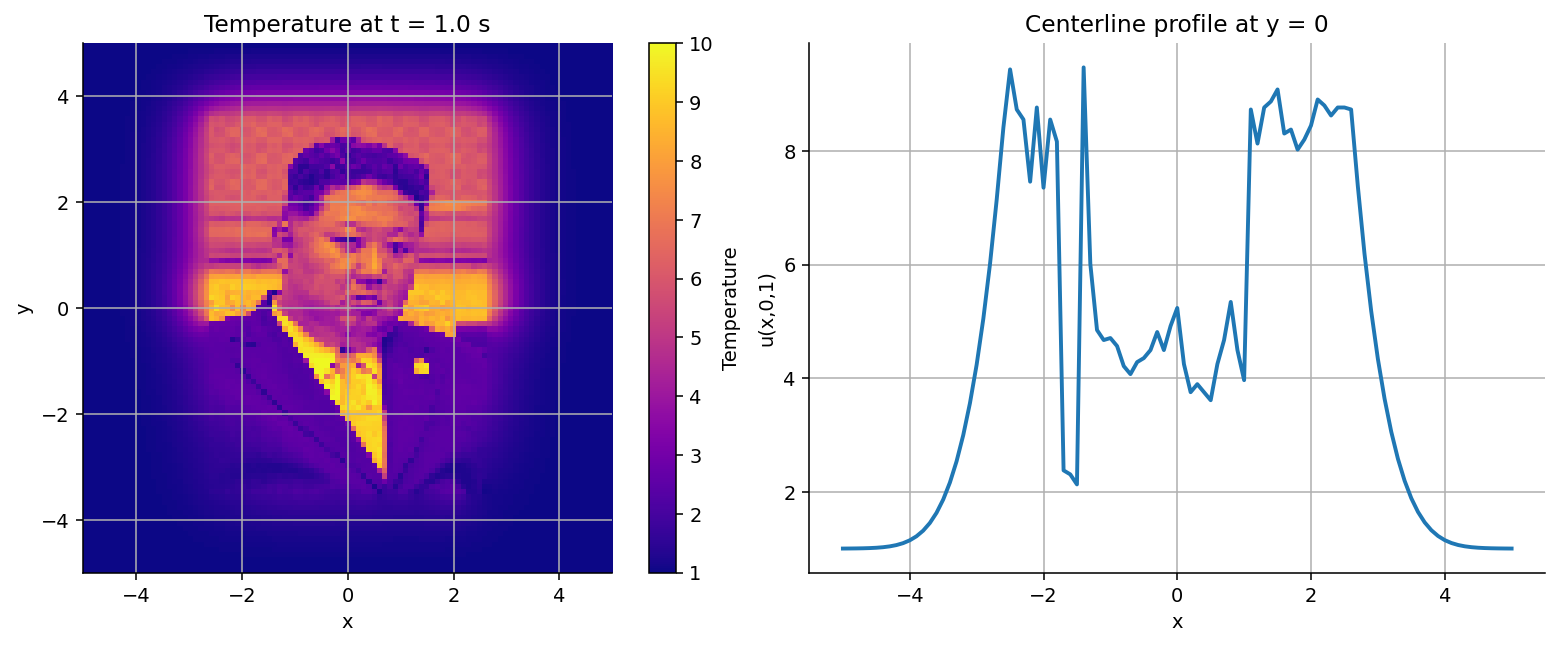

In [121]:
# Final-state visualization and a centerline profile
T_final = result6["T"]
x = result6["x"]
y = result6["y"]
j_mid = len(y) // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

im = axes[0].imshow(
    T_final.T,
    extent=[x[0], x[-1], y[0], y[-1]],
    origin="lower",
    cmap="plasma",
    vmin=1.0,
    vmax=10.0,
    aspect="equal",
)
axes[0].set_title("Temperature at t = 1.0 s")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im, ax=axes[0], label="Temperature")

axes[1].plot(x, T_final[:, j_mid], lw=2)
axes[1].set_title("Centerline profile at y = 0")
axes[1].set_xlabel("x")
axes[1].set_ylabel("u(x,0,1)")

plt.show()

## Problem 6(b): Interpretation

从时序图可以看到：

- 初始时刻，图像区域已经按灰度值被映射成不同强度的固定温度源；
- 亮度越高的区域温度越高，因此图像中的明暗结构会直接投影到温度场中；
- 随时间推进，热量从高温像素向周围低温区域扩散；
- 外边界始终固定为 `1`，因此整体温度场会在“内部图像热源”和“外边界冷却”之间形成平衡趋势。

这使得 Problem 6 不再是单一常温热源，而是一个**空间变温的 Dirichlet 热源**。如果你想改成“越暗越热”，只需要把灰度映射替换成 `1 - gray` 即可。

## Problem 6(c): If the Outer Boundary Has Constant Flux

若外边界不再给定 Dirichlet 温度，而是给定常通量

\[
\frac{\partial u}{\partial n}=g,
\]

则需要把边界点从“已知温度”改成“由法向导数关系消去”的 ghost-point 形式。以底边界为例，外法向指向 `-y` 方向，因此

\[
g = \frac{\partial u}{\partial n} = -u_y
\approx -\frac{u_{i,1}-u_{i,0}}{h_y},
\]

从而

\[
u_{i,0}=u_{i,1}+h_y g.
\]

把这个关系代回第一层内点 `(i,1)` 的五点差分式：

\[
\frac{u_{i,2}-2u_{i,1}+u_{i,0}}{h_y^2}
=
\frac{u_{i,2}-u_{i,1}}{h_y^2}+\frac{g}{h_y}.
\]

所以矩阵修改规律是：

- 原本法向方向上的二阶差分 `(+1,-2,+1)/h_y^2` 变成单边形式；
- 与边界 ghost value 对应的那一项不再留在矩阵里，而是转移到右端项；
- 因而**矩阵靠边界的那一行系数会改变，右端向量同时增加一个与 `g/h` 成正比的项**。

对其它三条边也完全类似，只需按各自外法向方向处理符号即可。

## Problem 6(d): Why Triangular Meshes

矩形网格的优点是实现简单、差分模板直接、计算高效；但它的局限也很明显：

- 对曲边、尖角、复杂障碍物的贴合能力弱；
- 很难局部加密，自适应能力差；
- 几何边界常被“阶梯化”近似。

三角网格更适合复杂区域，因为它可以：

- 更自然地逼近任意曲线边界；
- 在局部高梯度区域做局部加密；
- 与有限元方法天然兼容。

因此，对像本题这种带有复杂内部边界的热传导问题，矩形网格适合作为入门实现；如果几何更复杂或需要更高几何精度，三角网格 FEM 会是更合理的选择。